In [3]:
import json
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)


from freezeplots.paths import PROC_DATA_DIR, PLOT_DIR, CHANNEL_LAYOUT_PATH
with CHANNEL_LAYOUT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    channel_layout = json.load(file)
    
input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "2D_BoxPlot.png"

experiment_group
EJ19B1    16
EJ20B1    16
EJ21B1    16
EJ22B1    16
EJ23B1    10
dtype: int64


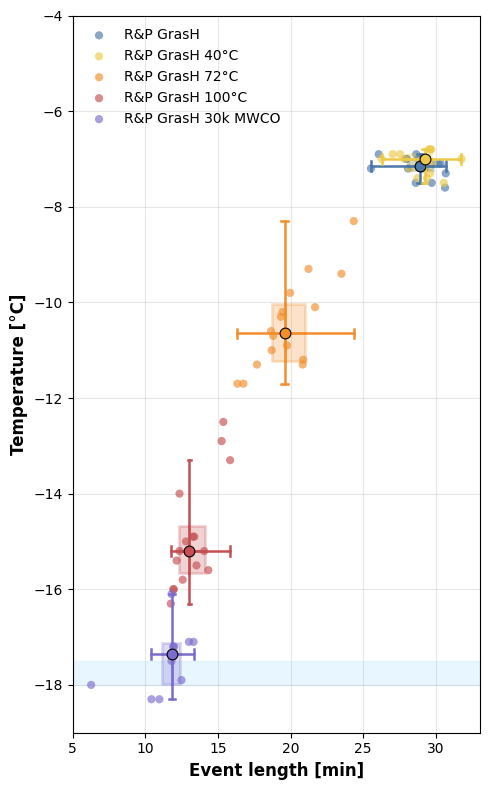

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "2D_BoxPlot_Gras.png"
# ============================================================
# Experiment grouping
# ============================================================

experiment_groups = {

    # Grasshopper
    "EJ19B1": "EJ19B1",
    "EJ20B1": "EJ20B1",
    "EJ21B1": "EJ21B1",
    "EJ22B1": "EJ22B1",
    "EJ23B1": "EJ23B1",


}


# ============================================================
# Plotting order
# ============================================================

experiment_order = [
    # Soil
    # "EJ09B1 + EJ09B2",

    # Grasshopper
    "EJ19B1",
    "EJ20B1",
    "EJ21B1",
    "EJ22B1",
    "EJ23B1",


]


# ============================================================
# Colors
# ============================================================
#
# Sample identity is represented by hue:
#   Soil         -> brown
#   Grasshopper  -> green
#   Weta         -> purple
#   Cave weta/CR -> blue
#
# Within each sample family:
#   untreated -> light
#   40°C      -> medium-light
#   72°C      -> medium-dark
#   100°C     -> dark
#   30 kDa    -> contrasting related color

experiment_colors = {
    # --------------------------------------------------------
    # Grasshopper
    # --------------------------------------------------------

    "EJ19B1": "#4C78A8",  # untreated — vivid green
    "EJ20B1": "#EDC948",  # 40°C — yellow-green
    "EJ21B1": "#F28E2B",  # 72°C — teal-green
    "EJ22B1": "#C44E52",  # 100°C — dark green
    "EJ23B1": "#7B6DCC",  # 30 kDa MWCO — cyan



}

# ============================================================
# Select and prepare data
# ============================================================

selected_experiments = list(experiment_groups)

plot_df = df.loc[
    df["experiment_id"].isin(selected_experiments)
].copy()

plot_df["experiment_group"] = (
    plot_df["experiment_id"].map(experiment_groups)
)

# Exclude measurements without a clear event
plot_df = plot_df.loc[
    ~plot_df["no_clear_event"].fillna(False)
].copy()

# Calculate event duration
plot_df["event_length_min"] = (
    plot_df["end_time_min"]
    - plot_df["start_time_min"]
)


# ============================================================
# Retrieve labels from channel_layout
# ============================================================

def retrieve_channel_label(row):
    experiment_id = str(row["experiment_id"]).strip()
    channel = str(row["channel"]).strip()

    try:
        return channel_layout[experiment_id][channel]

    except KeyError as error:
        raise KeyError(
            "No channel-layout label found for "
            f"{experiment_id}/{channel}."
        ) from error


plot_df["sample_label"] = plot_df.apply(
    retrieve_channel_label,
    axis=1,
)


# Exclude controls and deleted entries
excluded_labels = {
    "H2O Control",
    "TO DELETE",
}

plot_df = plot_df.loc[
    ~plot_df["sample_label"].isin(excluded_labels)
].copy()


# Remove incomplete and invalid rows
plot_df = plot_df.dropna(
    subset=[
        "experiment_group",
        "sample_label",
        "start_temp_c",
        "event_length_min",
    ]
).copy()

plot_df = plot_df.loc[
    plot_df["event_length_min"] >= 0
].copy()


# ============================================================
# Verify that every requested experiment has usable data
# ============================================================

available_counts = (
    plot_df.groupby("experiment_group")
    .size()
    .reindex(experiment_order, fill_value=0)
)

print(available_counts)

missing_groups = available_counts[
    available_counts == 0
].index.tolist()

if missing_groups:
    print(
        "Warning: no usable measurements remain for:",
        missing_groups,
    )
# ============================================================
# 2D boxplot helper
# ============================================================

def draw_2d_boxplot(
    ax,
    x,
    y,
    *,
    color,
    label,
    alpha_box=0.25,
    alpha_points=0.65,
    point_size=35,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) == 0:
        return

    # Individual observations
    ax.scatter(
        x,
        y,
        s=point_size,
        color=color,
        edgecolors="none",
        alpha=alpha_points,
        label=label,
        zorder=2,
    )

    # Quartiles and medians
    x_q1, x_median, x_q3 = np.percentile(
        x,
        [25, 50, 75],
    )

    y_q1, y_median, y_q3 = np.percentile(
        y,
        [25, 50, 75],
    )

    x_iqr = x_q3 - x_q1
    y_iqr = y_q3 - y_q1

    # Whisker boundaries
    x_lower_limit = x_q1 - 1.5 * x_iqr
    x_upper_limit = x_q3 + 1.5 * x_iqr

    y_lower_limit = y_q1 - 1.5 * y_iqr
    y_upper_limit = y_q3 + 1.5 * y_iqr

    x_whisker_low = np.min(
        x[x >= x_lower_limit]
    )

    x_whisker_high = np.max(
        x[x <= x_upper_limit]
    )

    y_whisker_low = np.min(
        y[y >= y_lower_limit]
    )

    y_whisker_high = np.max(
        y[y <= y_upper_limit]
    )

    # 2D interquartile rectangle
    rectangle = Rectangle(
        (x_q1, y_q1),
        x_q3 - x_q1,
        y_q3 - y_q1,
        facecolor=color,
        edgecolor=color,
        linewidth=2,
        alpha=alpha_box,
        zorder=3,
    )

    ax.add_patch(rectangle)

    # Median lines
    ax.plot(
        [x_median, x_median],
        [y_q1, y_q3],
        color=color,
        linewidth=2,
        zorder=4,
    )

    ax.plot(
        [x_q1, x_q3],
        [y_median, y_median],
        color=color,
        linewidth=2,
        zorder=4,
    )

    # Horizontal whiskers
    ax.plot(
        [x_whisker_low, x_q1],
        [y_median, y_median],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_q3, x_whisker_high],
        [y_median, y_median],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Vertical whiskers
    ax.plot(
        [x_median, x_median],
        [y_whisker_low, y_q1],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median, x_median],
        [y_q3, y_whisker_high],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Whisker caps
    x_cap_size = max(
        0.03 * np.ptp(x),
        0.1,
    )

    y_cap_size = max(
        0.03 * np.ptp(y),
        0.1,
    )

    ax.plot(
        [x_whisker_low, x_whisker_low],
        [y_median - y_cap_size, y_median + y_cap_size],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_whisker_high, x_whisker_high],
        [y_median - y_cap_size, y_median + y_cap_size],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median - x_cap_size, x_median + x_cap_size],
        [y_whisker_low, y_whisker_low],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median - x_cap_size, x_median + x_cap_size],
        [y_whisker_high, y_whisker_high],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Median point
    ax.scatter(
        [x_median],
        [y_median],
        s=60,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
    )



# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(5, 8)
)

for experiment_group in experiment_order:
    group_df = plot_df.loc[
        plot_df["experiment_group"] == experiment_group
    ]

    if group_df.empty:
        print(
            f"Warning: no usable data found for "
            f"{experiment_group!r}."
        )
        continue

    sample_labels = (
        group_df["sample_label"]
        .dropna()
        .unique()
        .tolist()
    )

    if len(sample_labels) != 1:
        raise ValueError(
            f"{experiment_group!r} contains multiple labels: "
            f"{sample_labels}"
        )

    sample_label = sample_labels[0]

    draw_2d_boxplot(
        ax=ax,
        x=group_df["event_length_min"],
        y=group_df["start_temp_c"],
        color=experiment_colors[experiment_group],
        label=sample_label,
    )


# ============================================================
# Water-freezing range
# ============================================================

ax.axhspan(
    -18.0,
    -17.5,
    color="#BFE7FF",
    alpha=0.35,
    zorder=0,
)


# ============================================================
# Figure formatting
# ============================================================

ax.set_xlabel(
    "Event length [min]",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Temperature [°C]",
    fontsize=12,
    fontweight="bold",
)


ax.grid(
    alpha=0.3,
)

ax.legend(
    # title="Sample",
    frameon=False,
    bbox_to_anchor=(0, 1.0),
    loc="upper left",
)
ax.set_ylim(-19, -4)

plt.tight_layout()
plt.savefig(output_path)
plt.show()

experiment_group
EJ24B1    16
EJ25B1    16
EJ26B1    16
EJ27B1    16
EJ18B1    11
dtype: int64


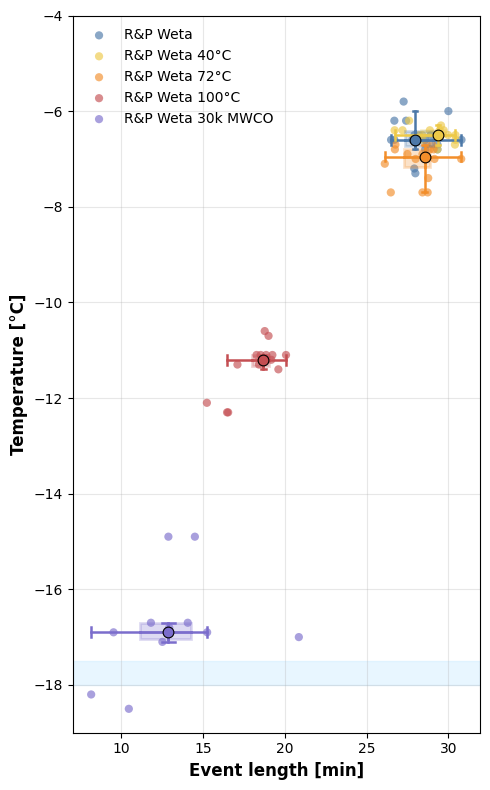

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "2D_BoxPlot_Weta.png"
# ============================================================
# Experiment grouping
# ============================================================

experiment_groups = {


    # Weta
    "EJ24B1": "EJ24B1",
    "EJ25B1": "EJ25B1",
    "EJ26B1": "EJ26B1",
    "EJ27B1": "EJ27B1",
    "EJ18B1": "EJ18B1",


}


# ============================================================
# Plotting order
# ============================================================

experiment_order = [

    # Weta
    "EJ24B1",
    "EJ25B1",
    "EJ26B1",
    "EJ27B1",
    "EJ18B1",


]


experiment_colors = {


    # --------------------------------------------------------
    # Weta
    # --------------------------------------------------------
    "EJ18B1": "#7B6DCC",   # teal
    "EJ24B1": "#4C78A8",  # untreated — pink
    "EJ25B1": "#EDC948",  # 40°C — magenta
    "EJ26B1": "#F28E2B",  # 72°C — purple
    "EJ27B1": "#C44E52",  # 100°C — dark violet


}

# ============================================================
# Select and prepare data
# ============================================================

selected_experiments = list(experiment_groups)

plot_df = df.loc[
    df["experiment_id"].isin(selected_experiments)
].copy()

plot_df["experiment_group"] = (
    plot_df["experiment_id"].map(experiment_groups)
)

# Exclude measurements without a clear event
plot_df = plot_df.loc[
    ~plot_df["no_clear_event"].fillna(False)
].copy()

# Calculate event duration
plot_df["event_length_min"] = (
    plot_df["end_time_min"]
    - plot_df["start_time_min"]
)


# ============================================================
# Retrieve labels from channel_layout
# ============================================================

def retrieve_channel_label(row):
    experiment_id = str(row["experiment_id"]).strip()
    channel = str(row["channel"]).strip()

    try:
        return channel_layout[experiment_id][channel]

    except KeyError as error:
        raise KeyError(
            "No channel-layout label found for "
            f"{experiment_id}/{channel}."
        ) from error


plot_df["sample_label"] = plot_df.apply(
    retrieve_channel_label,
    axis=1,
)


# Exclude controls and deleted entries
excluded_labels = {
    "H2O Control",
    "TO DELETE",
}

plot_df = plot_df.loc[
    ~plot_df["sample_label"].isin(excluded_labels)
].copy()


# Remove incomplete and invalid rows
plot_df = plot_df.dropna(
    subset=[
        "experiment_group",
        "sample_label",
        "start_temp_c",
        "event_length_min",
    ]
).copy()

plot_df = plot_df.loc[
    plot_df["event_length_min"] >= 0
].copy()


# ============================================================
# Verify that every requested experiment has usable data
# ============================================================

available_counts = (
    plot_df.groupby("experiment_group")
    .size()
    .reindex(experiment_order, fill_value=0)
)

print(available_counts)

missing_groups = available_counts[
    available_counts == 0
].index.tolist()

if missing_groups:
    print(
        "Warning: no usable measurements remain for:",
        missing_groups,
    )
# ============================================================
# 2D boxplot helper
# ============================================================

def draw_2d_boxplot(
    ax,
    x,
    y,
    *,
    color,
    label,
    alpha_box=0.25,
    alpha_points=0.65,
    point_size=35,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) == 0:
        return

    # Individual observations
    ax.scatter(
        x,
        y,
        s=point_size,
        color=color,
        edgecolors="none",
        alpha=alpha_points,
        label=label,
        zorder=2,
    )

    # Quartiles and medians
    x_q1, x_median, x_q3 = np.percentile(
        x,
        [25, 50, 75],
    )

    y_q1, y_median, y_q3 = np.percentile(
        y,
        [25, 50, 75],
    )

    x_iqr = x_q3 - x_q1
    y_iqr = y_q3 - y_q1

    # Whisker boundaries
    x_lower_limit = x_q1 - 1.5 * x_iqr
    x_upper_limit = x_q3 + 1.5 * x_iqr

    y_lower_limit = y_q1 - 1.5 * y_iqr
    y_upper_limit = y_q3 + 1.5 * y_iqr

    x_whisker_low = np.min(
        x[x >= x_lower_limit]
    )

    x_whisker_high = np.max(
        x[x <= x_upper_limit]
    )

    y_whisker_low = np.min(
        y[y >= y_lower_limit]
    )

    y_whisker_high = np.max(
        y[y <= y_upper_limit]
    )

    # 2D interquartile rectangle
    rectangle = Rectangle(
        (x_q1, y_q1),
        x_q3 - x_q1,
        y_q3 - y_q1,
        facecolor=color,
        edgecolor=color,
        linewidth=2,
        alpha=alpha_box,
        zorder=3,
    )

    ax.add_patch(rectangle)

    # Median lines
    ax.plot(
        [x_median, x_median],
        [y_q1, y_q3],
        color=color,
        linewidth=2,
        zorder=4,
    )

    ax.plot(
        [x_q1, x_q3],
        [y_median, y_median],
        color=color,
        linewidth=2,
        zorder=4,
    )

    # Horizontal whiskers
    ax.plot(
        [x_whisker_low, x_q1],
        [y_median, y_median],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_q3, x_whisker_high],
        [y_median, y_median],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Vertical whiskers
    ax.plot(
        [x_median, x_median],
        [y_whisker_low, y_q1],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median, x_median],
        [y_q3, y_whisker_high],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Whisker caps
    x_cap_size = max(
        0.03 * np.ptp(x),
        0.1,
    )

    y_cap_size = max(
        0.03 * np.ptp(y),
        0.1,
    )

    ax.plot(
        [x_whisker_low, x_whisker_low],
        [y_median - y_cap_size, y_median + y_cap_size],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_whisker_high, x_whisker_high],
        [y_median - y_cap_size, y_median + y_cap_size],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median - x_cap_size, x_median + x_cap_size],
        [y_whisker_low, y_whisker_low],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median - x_cap_size, x_median + x_cap_size],
        [y_whisker_high, y_whisker_high],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Median point
    ax.scatter(
        [x_median],
        [y_median],
        s=60,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
    )



# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(5, 8)
)

for experiment_group in experiment_order:
    group_df = plot_df.loc[
        plot_df["experiment_group"] == experiment_group
    ]

    if group_df.empty:
        print(
            f"Warning: no usable data found for "
            f"{experiment_group!r}."
        )
        continue

    sample_labels = (
        group_df["sample_label"]
        .dropna()
        .unique()
        .tolist()
    )

    if len(sample_labels) != 1:
        raise ValueError(
            f"{experiment_group!r} contains multiple labels: "
            f"{sample_labels}"
        )

    sample_label = sample_labels[0]

    draw_2d_boxplot(
        ax=ax,
        x=group_df["event_length_min"],
        y=group_df["start_temp_c"],
        color=experiment_colors[experiment_group],
        label=sample_label,
    )


# ============================================================
# Water-freezing range
# ============================================================

ax.axhspan(
    -18.0,
    -17.5,
    color="#BFE7FF",
    alpha=0.35,
    zorder=0,
)

# ============================================================
# Figure formatting
# ============================================================

ax.set_xlabel(
    "Event length [min]",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Temperature [°C]",
    fontsize=12,
    fontweight="bold",
)


ax.grid(
    alpha=0.3,
)

ax.legend(
    # title="Sample",
    frameon=False,
    bbox_to_anchor=(0, 1.0),
    loc="upper left",
)
ax.set_ylim(-19, -4)

plt.tight_layout()
plt.savefig(output_path)
plt.show()

experiment_group
EJ29B1    16
EJ30B1    16
EJ31B1    16
EJ32B1    16
EJ33B1     8
dtype: int64


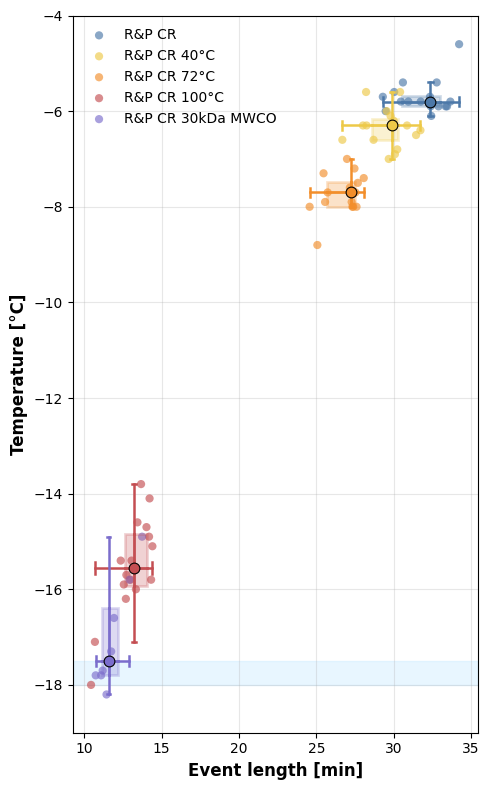

In [56]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "2D_BoxPlot_CR.png"
# ============================================================
# Experiment grouping
# ============================================================

experiment_groups = {

    # Cave weta / CR
    "EJ29B1": "EJ29B1",
    "EJ30B1": "EJ30B1",
    "EJ31B1": "EJ31B1",
    "EJ32B1": "EJ32B1",
    "EJ33B1": "EJ33B1",
}


# ============================================================
# Plotting order
# ============================================================

experiment_order = [
    # Soil
    # "EJ09B1 + EJ09B2",

    # Cave weta / CR
    "EJ29B1",
    "EJ30B1",
    "EJ31B1",
    "EJ32B1",
    "EJ33B1",
]


experiment_colors = {

    # --------------------------------------------------------
    # Cave weta / CR
    # --------------------------------------------------------

    "EJ29B1": "#4C78A8",  # untreated — light blue
    "EJ30B1": "#EDC948",  # 40°C — blue
    "EJ31B1": "#F28E2B",  # 72°C — indigo-blue
    "EJ32B1": "#C44E52",  # 100°C — navy
    "EJ33B1": "#7B6DCC",  # 30 kDa MWCO — orange accent
}



# ============================================================
# Select and prepare data
# ============================================================

selected_experiments = list(experiment_groups)

plot_df = df.loc[
    df["experiment_id"].isin(selected_experiments)
].copy()

plot_df["experiment_group"] = (
    plot_df["experiment_id"].map(experiment_groups)
)

# Exclude measurements without a clear event
plot_df = plot_df.loc[
    ~plot_df["no_clear_event"].fillna(False)
].copy()

# Calculate event duration
plot_df["event_length_min"] = (
    plot_df["end_time_min"]
    - plot_df["start_time_min"]
)


# ============================================================
# Retrieve labels from channel_layout
# ============================================================

def retrieve_channel_label(row):
    experiment_id = str(row["experiment_id"]).strip()
    channel = str(row["channel"]).strip()

    try:
        return channel_layout[experiment_id][channel]

    except KeyError as error:
        raise KeyError(
            "No channel-layout label found for "
            f"{experiment_id}/{channel}."
        ) from error


plot_df["sample_label"] = plot_df.apply(
    retrieve_channel_label,
    axis=1,
)


# Exclude controls and deleted entries
excluded_labels = {
    "H2O Control",
    "TO DELETE",
}

plot_df = plot_df.loc[
    ~plot_df["sample_label"].isin(excluded_labels)
].copy()


# Remove incomplete and invalid rows
plot_df = plot_df.dropna(
    subset=[
        "experiment_group",
        "sample_label",
        "start_temp_c",
        "event_length_min",
    ]
).copy()

plot_df = plot_df.loc[
    plot_df["event_length_min"] >= 0
].copy()


# ============================================================
# Verify that every requested experiment has usable data
# ============================================================

available_counts = (
    plot_df.groupby("experiment_group")
    .size()
    .reindex(experiment_order, fill_value=0)
)

print(available_counts)

missing_groups = available_counts[
    available_counts == 0
].index.tolist()

if missing_groups:
    print(
        "Warning: no usable measurements remain for:",
        missing_groups,
    )
# ============================================================
# 2D boxplot helper
# ============================================================

def draw_2d_boxplot(
    ax,
    x,
    y,
    *,
    color,
    label,
    alpha_box=0.25,
    alpha_points=0.65,
    point_size=35,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) == 0:
        return

    # Individual observations
    ax.scatter(
        x,
        y,
        s=point_size,
        color=color,
        edgecolors="none",
        alpha=alpha_points,
        label=label,
        zorder=2,
    )

    # Quartiles and medians
    x_q1, x_median, x_q3 = np.percentile(
        x,
        [25, 50, 75],
    )

    y_q1, y_median, y_q3 = np.percentile(
        y,
        [25, 50, 75],
    )

    x_iqr = x_q3 - x_q1
    y_iqr = y_q3 - y_q1

    # Whisker boundaries
    x_lower_limit = x_q1 - 1.5 * x_iqr
    x_upper_limit = x_q3 + 1.5 * x_iqr

    y_lower_limit = y_q1 - 1.5 * y_iqr
    y_upper_limit = y_q3 + 1.5 * y_iqr

    x_whisker_low = np.min(
        x[x >= x_lower_limit]
    )

    x_whisker_high = np.max(
        x[x <= x_upper_limit]
    )

    y_whisker_low = np.min(
        y[y >= y_lower_limit]
    )

    y_whisker_high = np.max(
        y[y <= y_upper_limit]
    )

    # 2D interquartile rectangle
    rectangle = Rectangle(
        (x_q1, y_q1),
        x_q3 - x_q1,
        y_q3 - y_q1,
        facecolor=color,
        edgecolor=color,
        linewidth=2,
        alpha=alpha_box,
        zorder=3,
    )

    ax.add_patch(rectangle)

    # Median lines
    ax.plot(
        [x_median, x_median],
        [y_q1, y_q3],
        color=color,
        linewidth=2,
        zorder=4,
    )

    ax.plot(
        [x_q1, x_q3],
        [y_median, y_median],
        color=color,
        linewidth=2,
        zorder=4,
    )

    # Horizontal whiskers
    ax.plot(
        [x_whisker_low, x_q1],
        [y_median, y_median],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_q3, x_whisker_high],
        [y_median, y_median],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Vertical whiskers
    ax.plot(
        [x_median, x_median],
        [y_whisker_low, y_q1],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median, x_median],
        [y_q3, y_whisker_high],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Whisker caps
    x_cap_size = max(
        0.03 * np.ptp(x),
        0.1,
    )

    y_cap_size = max(
        0.03 * np.ptp(y),
        0.1,
    )

    ax.plot(
        [x_whisker_low, x_whisker_low],
        [y_median - y_cap_size, y_median + y_cap_size],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_whisker_high, x_whisker_high],
        [y_median - y_cap_size, y_median + y_cap_size],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median - x_cap_size, x_median + x_cap_size],
        [y_whisker_low, y_whisker_low],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    ax.plot(
        [x_median - x_cap_size, x_median + x_cap_size],
        [y_whisker_high, y_whisker_high],
        color=color,
        linewidth=1.8,
        zorder=4,
    )

    # Median point
    ax.scatter(
        [x_median],
        [y_median],
        s=60,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
    )



# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(5, 8)
)

for experiment_group in experiment_order:
    group_df = plot_df.loc[
        plot_df["experiment_group"] == experiment_group
    ]

    if group_df.empty:
        print(
            f"Warning: no usable data found for "
            f"{experiment_group!r}."
        )
        continue

    sample_labels = (
        group_df["sample_label"]
        .dropna()
        .unique()
        .tolist()
    )

    if len(sample_labels) != 1:
        raise ValueError(
            f"{experiment_group!r} contains multiple labels: "
            f"{sample_labels}"
        )

    sample_label = sample_labels[0]

    draw_2d_boxplot(
        ax=ax,
        x=group_df["event_length_min"],
        y=group_df["start_temp_c"],
        color=experiment_colors[experiment_group],
        label=sample_label,
    )


# ============================================================
# Water-freezing range
# ============================================================

ax.axhspan(
    -18.0,
    -17.5,
    color="#BFE7FF",
    alpha=0.35,
    zorder=0,
)

# ============================================================
# Figure formatting
# ============================================================

ax.set_xlabel(
    "Event length [min]",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Temperature [°C]",
    fontsize=12,
    fontweight="bold",
)


ax.grid(
    alpha=0.3,
)

ax.legend(
    # title="Sample",
    frameon=False,
    bbox_to_anchor=(0, 1.0),
    loc="upper left",
)
ax.set_ylim(-19, -4)

plt.tight_layout()
plt.savefig(output_path)
plt.show()
